In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [4]:
rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']


chains_runs = []
for dir in rundirs:
    chains_surveys = []
    for survey in survey_labels:
        chains = []
        for setup in setups:
            path = f"{base_dir}/inference/{dir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                s, l = utils.load_samples(path)
                chains.append(s)

        chains_surveys.append(chains)
    chains_runs.append(chains_surveys)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/SO-LAT/noiseless...
Load

In [5]:
true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
true_params

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[np.float64(-1.7166987712964503),
 np.float64(0.0),
 np.float64(3.277127671229863),
 np.float64(8.53),
 np.float64(0.275),
 np.float64(0.05526446348700878)]

In [6]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 0
chains = chains_all[index]


for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

NameError: name 'chains_all' is not defined

<Figure size 1000x1000 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups):
        chain = chains[n]
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [n+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{label}', fontsize=12)


In [37]:
def plot_corner(samples, axes, label=None, **kwargs):
    x, y, z, t = samples.T

    sns.kdeplot(x=x, y=y, levels=5,
            ax=ax[1,0], **kwargs)
    sns.kdeplot(x=y, y=z, levels=5,
                ax=ax[2,1], **kwargs)
    sns.kdeplot(x=x, y=z, levels=5,
                ax=ax[2,0], **kwargs)

    sns.kdeplot(x=x, ax=ax[0,0], label=label, **kwargs)
    sns.kdeplot(x=y, ax=ax[1,1], **kwargs)
    sns.kdeplot(x=z, ax=ax[2,2], **kwargs)

    return axes

In [40]:
len(chains_runs[-1])

3

In [51]:
rundirs[-1]

'productionruns3_mechaemu_simu10818'

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)
(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(19200, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


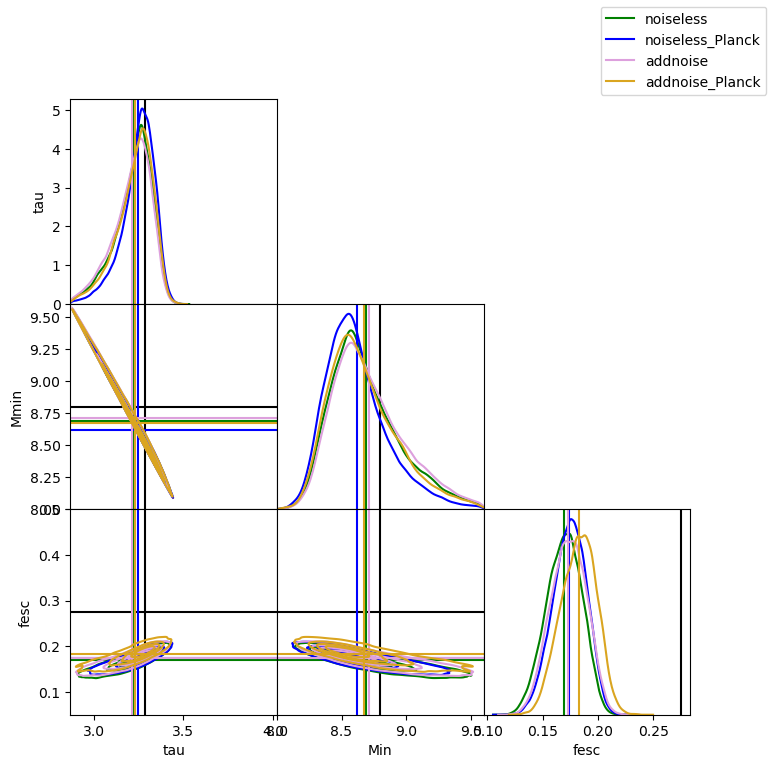

In [53]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

line_kwargs = {}

line_kwargs['color'] = 'black'

sn = '10818'
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]
plot_vlines(true_params[2:], ax, **line_kwargs)

for i, chain in enumerate(chains_runs[-1][0]):
    print(chain.shape)
    line_kwargs['color'] = colors[i]
    samples = make_tauchains(chain, truths=df.loc[sn].to_dict())
    plot_corner(samples, ax, label=f'{setups[i]}', **line_kwargs)
    plot_vlines(np.mean(samples, axis=0), ax, **line_kwargs)

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

In [ ]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)


plot_vlines(true_params[2:], ax, color='black')

sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
             color='grey', ax=ax[1,0], ls='-')
sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
             color='grey', ax=ax[2,1], ls='--')
sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
             color='grey', ax=ax[2,0], ls='--')

sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='gray', label='previous run')
sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='gray')
sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='gray')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,1], levels=5,
             color=colors[4], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,1], levels=5,
             color='black', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_prior[:,1], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], ax=ax[0,0], ls='-', color='black', label=f'3 param prior')
sns.kdeplot(x=samples_prior[:,1], ax=ax[1,1], ls='-', color='black')
sns.kdeplot(x=samples_prior[:,2], ax=ax[2,2], ls='-', color='black')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], ax=ax[0,0], ls='-', color=colors[4], label='tau/Mmin/fesc')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], ax=ax[1,1], ls='-', color=colors[4])
sns.kdeplot(x=samples_tau_Mmin_fesc[:,2], ax=ax[2,2], ls='-', color=colors[4])

sns.kdeplot(x=samples_tau_Mmin[:,0], ax=ax[0,0], color=colors[0], label='tau/Min')
sns.kdeplot(x=samples_tau_Mmin[:,1], ax=ax[1,1], color=colors[0])
sns.kdeplot(x=samples_tau_Mmin[:,0], y=samples_tau_Mmin[:,1], levels=5, ax=ax[1,0], color=colors[0])

sns.kdeplot(x=samples_Mmin_fesc[:,0], ax=ax[1,1], ls='--', color=colors[2], label='Mmin/fesc')
sns.kdeplot(x=samples_Mmin_fesc[:,1], ax=ax[2,2], ls='--', color=colors[2],)
sns.kdeplot(x=samples_Mmin_fesc[:,0], y=samples_Mmin_fesc[:,1], color=colors[2], levels=5, ax=ax[2,1], ls='--')

sns.kdeplot(x=samples_tau_fesc[:,0], ax=ax[0,0], ls='--', color=colors[3], label='tau/fesc')
sns.kdeplot(x=samples_tau_fesc[:,1], ax=ax[2,2], ls='--', color=colors[3])
sns.kdeplot(x=samples_tau_fesc[:,0], y=samples_tau_fesc[:,1], levels=5, color=colors[3], ax=ax[2,0], ls=':')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,1], levels=5,
             color=colors[5], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], ax=ax[0,0], ls='-', color=colors[5], label=f'3% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], ax=ax[1,1], ls='-', color=colors[5])
sns.kdeplot(x=samples_Mmin_prior_3percent[:,2], ax=ax[2,2], ls='-', color=colors[5])


sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,1], levels=5,
             color=colors[6], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], ax=ax[0,0], ls='-', color=colors[6], label=f'2% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], ax=ax[1,1], ls='-', color=colors[6])
sns.kdeplot(x=samples_Mmin_prior_2percent[:,2], ax=ax[2,2], ls='-', color=colors[6])


sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,1], levels=5,
             color='violet', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], ax=ax[0,0], ls='-', color='violet', label=f'1% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], ax=ax[1,1], ls='-', color='violet')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,2], ax=ax[2,2], ls='-', color='violet')

s, l = utils.load_samples(f"{base_dir}/inference/productionruns_justpriors/CMB-HD")

# sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
#              color='red', ax=ax[1,0], ls='-')
# sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
#              color='red', ax=ax[2,1], ls='--')
# sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
#              color='red', ax=ax[2,0], ls='--')

# sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='red', label=f'prior previous')
# sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='red')
# sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='red')

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            label = ''
            if i == 0:
                label = 'individual fit'
            sns.kdeplot(single_samples[i].flatten(), ax=axes, color=colors[1], zorder=0, label=label)
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()